# Working with Franka Robotcs robot via **panda-py**

This notebook introduces the **panda-py** workflow for Franka Rbotics robots in RobotBlockSet. Its purpose is to show how to connect to, monitor, and control robots using the **panda-py** interface.


## What this notebook covers

The examples below demonstrate the main steps for working with robot through **panda-py**, including initialization, state capture, command execution, and inspection of robot motion and feedback signals during runtime.

Use this notebook as a practical starting point when you want to control a Franak robots from RBS through the **panda-py** interface or adapt the same workflow to your own setup.


# Imports

In [1]:
import numpy as np
from time import perf_counter
import matplotlib.pyplot as plt
from robotblockset.transformations import map_pose, q_wxyz2xyzw, q_xyzw2wxyz, t2x
from robotblockset.tools import gradientPath, gradientCartesianPath

np.set_printoptions(formatter={"float": "{: 0.4f}".format})

`panda-py`is chatty. Therefore we activate only error log level.

In [ ]:
import logging
logging.basicConfig(level=logging.ERROR)

## Helper function for capturing robot states

The following function stores robot time, joint states, task-space states, and commanded references during motion. These recorded arrays are later used for plotting.


Capture measured and commanded platform and robot states into global arrays for later plotting.

In [3]:
it = 0
def CaptureRobot(r):
    global it, t_last, trun, tt, qt, rqt, qdt, rqdt, xt, vt, rxt, rvt, mt
    if it == 0:
        t_last = r.t
        trun = r.Time
        tt = t_last
        qt = r._actual.q
        qdt = r._actual.qdot
        rqt = r._command.q
        rqdt = r._command.qdot
        xt = r._actual.x
        vt = r._actual.v
        rxt = r._command.x
        rvt = r._command.v
        mt = r._command.mode
    elif r.t>t_last:
        t_last = r.t
        trun = np.vstack((trun, r.Time))
        tt = np.vstack((tt, t_last))
        qt = np.vstack((qt, r._actual.q))
        qdt = np.vstack((qdt, r._actual.qdot))
        rqt = np.vstack((rqt, r._command.q))
        rqdt = np.vstack((rqdt, r._command.qdot))
        xt = np.vstack((xt, r._actual.x))
        vt = np.vstack((vt, r._actual.v))
        rxt = np.vstack((rxt, r._command.x))
        rvt = np.vstack((rvt, r._command.v))
        mt = np.vstack((mt, r._command.mode))
    it += 1

# Franka robot class

Class `panda` in `robotblockset.franka.robots_pandapy` is a hardware-specific subclass of `robot`. The base [`robot`](/d:/Leon/Python/RBS/robotblockset/robots.py) defines the generic Robotblockset API: common state containers, coordinate-frame conversions, kinematics-based motion helpers, tool/load handling, and abstract control/status methods. The Panda implementation in [`robots_pandapy.py`](/d:/Leon/Python/RBS/robotblockset/franka/robots_pandapy.py) binds that API to a real Franka controller through `panda_py`/`libfranka`.

Compared to `robot`, `panda` adds Franka-specific behavior:

- it connects to the physical robot by `hostname` and exposes the low-level `panda_py.Panda`, robot, and model handles,
- it overrides state acquisition so `q`, `qdot`, torques, TCP pose, Jacobian-based velocity, external wrench, contact, and collision flags come directly from the Franka state,
- it provides native joint/cartesian execution (`JMove`, `CMove`, `GoTo_q`, `GoTo_X`) using Franka controllers instead of only the generic base implementation,
- it supports runtime switching between Franka controllers such as `JointImpedance` and `CartesianImpedance`,
- it adds Panda-specific compliance, collision-threshold, teaching-mode, EE frame, stiffness frame, and load management.

| Property | Description |
| --- | --- |
| `hostname` | Network address of the Panda/FR3 controller. |
| `panda` | `panda_py.Panda` communication object used to command the robot. |
| `robot` | Low-level Franka robot handle returned by `self.panda.get_robot()`. |
| `model` | Franka model handle used for dynamics/Jacobian/gravity computations. |
| `_franka_default` | Container of Franka default stiffness, damping, softness, and collision thresholds. |
| `strategy_controller_mapping` | Mapping from Robotblockset strategy names to Franka controller objects. |
| `ctrl` | Currently active Franka controller instance. |
| `joint_stiffness`, `joint_damping`, `joint_filter` | Current joint compliance settings used by Panda joint control. |
| `cartesian_impedance`, `cartesian_damping_ratio`, `cartesian_nullspace_stiffness`, `cartesian_filter` | Current Cartesian compliance settings for Panda Cartesian impedance control. |
| `joint_contacts`, `joint_collisions` | Contact/collision flags reported per joint by the Franka state. |
| `cartesian_contacts`, `cartesian_collisions` | Contact/collision flags reported for the Cartesian dimensions. |
| `StiffnessFrame` | Current Franka stiffness-frame transform (`EE_T_K`). |


The `panda` class provide additional properties and methods:

| Method/Property | Description |
| --- | --- |
| `J` | Panda-specific Jacobian property. Returns the `6 x 7` zero Jacobian from the Franka model for the selected frame (`"EE"`, `"Flange"`, `"Stiffness"`, or raw libfranka frame index). |
| `c` | Panda-specific Coriolis/centrifugal joint torque vector computed from the Franka model for the current robot state. |
| `g` | Panda-specific gravity compensation torque vector from the Franka model for the current robot state. |
| `H` | Panda-specific joint-space inertia matrix `H(q)` returned by the Franka model as a `7 x 7` matrix. |
| `FK(q, out)` | Analytical forward kinematics helper using `panda_py.fk(...)`. It returns the end-effector pose for joint configuration `q` in the requested Robotblockset format (`x`, `T`, `p`, `R`, ...). It assumes the default TCP. |
| `IK(T, q7, q_initial)` | Analytical inverse kinematics helper using `panda_py.ik(...)`. It computes a 7-joint solution for a target end-effector pose, optionally fixing joint 7 with `q7` and using `q_initial` as the initial guess. It assumes the default TCP. |


## Desk client

Use the Desk client to connect to the web-application running on the control unit to unlock the brakes and activate the Franka Research Interface (FCI) for robot torque control.

In [4]:
# import panda_py
# hostname = '192.168.0.3'
# username = 
# password = 
# desk = panda_py.Desk(hostname, username, password)
# desk.unlock()
# desk.activate_fci()

## Connect to the robot 

To connect to the robot we have to define the `hostname` of the robot. All arguments for the initialization are in the following tabel:

| Init Argument | Description |
| --- | --- |
| `hostname` | Hostname or IP address of the Panda/FR3 controller to connect to. Default is `"192.168.3.100"`. |
| `name` | User-facing name stored on the robot instance. Default is `"panda"`. |
| `model` | Robot model selector. Supported values are `"panda"` and `"fr3"`; it determines which robot specification is initialized before the hardware connection is created. |
| `control_strategy` | Initial Franka control strategy activated after initialization. Default is `"JointImpedance"`. |


In [5]:
from robotblockset.franka.robots_pandapy import panda
hostname = '192.168.0.23'
r = panda(hostname)

[RBS_INFO] [07:37:50] [Robot]: Initialized


## Connect to the gripper

Class `panda_gripper` is a Franka-specific gripper interface built on top of `libfranka.Gripper`. It connects to the gripper through the robot hostname, reads the current gripper state directly from the controller, and provides simple high-level operations such as width reading, grasping, moving, and homing.

| Property | Description |
| --- | --- |
| `Name` | Name of the gripper instance. |
| `Robot` | Reference to the robot object the gripper is attached to. |
| `hostname` | Network address used to connect to the Franka gripper controller. |
| `gripper` | Low-level `libfranka.Gripper` communication object. |
| `gripper_state` | Last state read from the gripper, including width and grasp status. |

To define a gripper object we can use the folowing arguments:

| Init Argument | Description |
| --- | --- |
| `robot` | Robot instance the gripper is attached to. If provided, the gripper uses `robot.hostname` for connection. |
| `name` | Name assigned to the gripper instance. Default is `"panda_gripper"`. |
| `hostname` | Hostname or IP address of the Franka controller. Used only when `robot` is `None`. |

In [6]:
from robotblockset.franka.grippers_pandapy import panda_gripper
g = panda_gripper(robot=r)
r.SetGripper(g)

# Control strategy

Class `panda` supports the following basic control strategies:

| Space | Strategies              |
| ----- | ------------------------|
| Joint | `'JointImpedance'`      |
| Task  | `'CartesianImpedance'`  |

If you add custom controllers to the `panda_py` package, the set of available controllers does not need to stay limited to the built-in ones. You can augment the list exposed in Robotblockset by extending the controller mapping so the new `panda_py` controller classes can also be selected and used through the same interface.


In [7]:
print(r.AvailableStrategies())

['JointImpedance', 'CartesianImpedance']


You can switch the startegy using `SetStrategy`.

In [8]:
r.SetStrategy("JointImpedance")

In each available impedance control strategies we can change the stiffness (compliance) of the robot using different methods. For more details see **tutorial_robots** notebook.

For example, to make robot compliant in joints, we can use:

In [9]:
r.SetJointSoft(0.01)

anfd to make it stiff again:

In [10]:
r.SetJointStiff()

## Teaching

One of the control modes is a **teaching** mode, where the user can move manualy the robot. The related methods are:

| Method | Description |
| --- | --- |
| `TeachingMode(mode, damping=None)` | Enables or disables gravity-compensated hand-guiding mode. Optional damping can be given as a scalar or 7D vector and is clipped to `[0, 1]`. |
| `SetTeachMode()` | Convenience method that enables teaching mode and reports the state change. |
| `EndTeachMode()` | Convenience method that disables teaching mode, resets the current target, and resumes the active controller. |


# Motion commands


All high-level motion commands are the same as for all robots. For more details see **tutorial_robots** notebook. However, there are differences in low-level motion commands.

In addition, `JMove(...)` and `CMove(...)` can forward Panda-specific controller tuning arguments through `**kwargs` to the low-level `GoTo_...` methods used during execution. In practice this means that, besides the usual timing and trajectory options, you can pass per-command compliance parameters such as joint `stiffness` and `damping` to `JMove(...)`, and Cartesian `impedance`, `damping`, and `R` to `CMove(...)`.

In the base [`robot`](/d:/Leon/Python/RBS/robotblockset/robots.py) class, these low-level methods are mostly generic interfaces and are left unimplemented for hardware subclasses. In `panda`, these methods are connected to the Franka controllers from `panda_py`, so they send real commands to the robot and update the commanded state consistently with the active control strategy.

`GoTo_T` is also specialized in `panda`: it converts poses to the robot base frame and then dispatches differently depending on strategy. In joint-style strategies it falls back to `GoTo_TC`, while in `CartesianImpedance` it calls the Panda-specific `GoTo_X`. This makes the Panda implementation strategy-aware, whereas the base class remains controller-agnostic.

| Method | Description |
| --- | --- |
| `GoTo_q(q, qdot=None, trq=None, wait=None, stiffness=None, damping=None, **kwargs)` | Sends a low-level joint command through the active Franka joint controller. Compared to the base `robot.GoTo_q`, it is fully implemented and does not raise `NotImplementedError`. The Panda-specific arguments `stiffness` and `damping` allow per-command joint compliance override before `set_control(q, qdot)`. The `trq` argument is present for API compatibility but is not actively used by this implementation. |
| `GoTo_T(x, v=None, FT=None, wait=None, **kwargs)` | Low-level task-space command that first converts the target pose/velocity according to `task_space` (`World`, `Robot`, or `Object`) and then routes execution based on the active Panda strategy. In joint strategies it calls `GoTo_TC`; in `CartesianImpedance` it calls `GoTo_X`. Relative to the base method, the Panda version is narrower and more explicit about supported strategies, and in practice `FT` is not used by the Panda Cartesian path. |
| `GoTo_X(x, v=None, FT=None, wait=None, impedance=None, damping=None, R=None, **kwargs)` | Sends a Cartesian pose command directly to the Panda Cartesian controller after converting the quaternion format expected by `panda_py`. This method is a key difference from `robot.GoTo_X`, which is abstract and raises `NotImplementedError`. The Panda-specific arguments `impedance`, `damping`, and `R` allow per-command tuning of Cartesian compliance before the controller receives the command. The `FT` argument is accepted for API compatibility but is not used here. |


In [11]:
r.JMove(r.q_home, t=2.0)
r.Wait(1)
r.SetCaptureCallback(CaptureRobot)
r.ResetTime()
it = 0
r.StartCapture()
r.CMoveFor([0.1, -0.2, 0.0], t=2.0)
r.Wait(1)
print("Joint positions:", r.q)
print("Task  positions:", r.x)
r.JMove(r.q_home, t=2.0)
r.Wait(1)
print("Joint positions:", r.q)
print("Task  positions:", r.x)
r.StopCapture()


Joint positions: [-0.2555 -0.3400 -0.1657 -2.0169 -0.0545  1.6793  0.3825]
Task  positions: [ 0.4067 -0.1988  0.4872  0.0007 -1.0000  0.0015  0.0007]
Joint positions: [-0.0011 -0.7846 -0.0005 -2.3539 -0.0022  1.5751  0.7791]
Task  positions: [ 0.3083 -0.0010  0.4882 -0.0009 -1.0000 -0.0024 -0.0029]


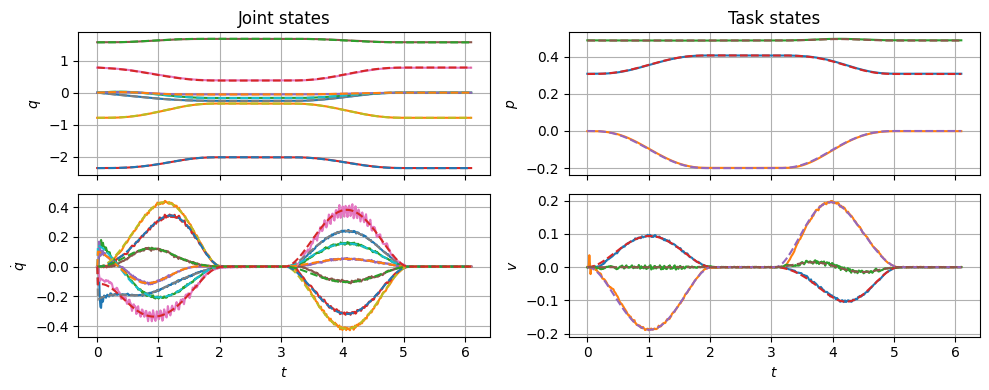

In [12]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].plot(tt, rqt, "--")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, "-")
ax[1, 0].plot(tt, rqdt, "--")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], "-")
ax[0, 1].plot(tt, rxt[:, :3], "--")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].plot(tt, rvt[:, :3], "--")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

## Use internal **panda_py** motion control

`JMove(...)` is the joint-space motion command: it moves the robot to a target joint configuration. `CMove(...)` is the Cartesian motion command: it moves the TCP to a target pose. By default, both methods use the Robotblockset motion layer (`_JMove` / `_CMove`), which follows the active control strategy and interpolates the motion inside Robotblockset.

Both commands also accept additional Panda-specific `**kwargs` that are forwarded to the low-level execution layer. For `JMove(...)`, this includes command-level joint `stiffness` and `damping`. For `CMove(...)`, this includes Cartesian `impedance`, `damping`, and the optional stiffness-frame rotation `R`.

If `use_internal=True`, the Panda-specific implementation bypasses that outer interpolation layer and calls the internal `panda_py` / `libfranka` motion generator directly. This is useful when you want the Franka controller to execute the move natively.

| Method | Description |
| --- | --- |
| `JMove(q, ..., use_internal=False, **kwargs)` | Joint-space move to target configuration `q`. With `use_internal=False`, Robotblockset generates and executes the motion with the current joint control strategy. With `use_internal=True`, it calls Franka's internal joint motion generator (`move_to_joint_position`). Additional Panda-specific `**kwargs` such as `stiffness` and `damping` are relevant when using the Robotblockset motion layer. |
| `CMove(x, ..., use_internal=False, **kwargs)` | Cartesian move to target TCP pose `x`. With `use_internal=False`, Robotblockset interpolates the Cartesian path and sends references through the active Cartesian controller. With `use_internal=True`, it calls Franka's internal Cartesian motion generator (`move_to_pose`). Additional Panda-specific `**kwargs` such as `impedance`, `damping`, and `R` are relevant when using the Robotblockset motion layer. |

> ℹ️ **Note:** When using internal motion robot states can not be captured using RBS capturing (`SetCaptureCallback`, `StartCapture` and `StopCapture`) but the `panda-py` capturing. Therefore, we have to define the buffer size for capture

| Method                    | Description                                                  |
| ------------------------- | ------------------------------------------------------------ |
| `StartCapture(use_internal=True, max_samples=40000)`            | Start internal capturing and define buffer size |
| `StopCapture()`             | Stop capturing                              |
| `GetLastCapturedData()`     | Get last internal captured data (dictionary)  |

In [13]:
r.JMove(r.q_home, t=2.0)
r.Wait(1)

r.StartCapture(use_internal=True, max_samples=40000)
r.CMoveFor([0.1, -0.2, 0.0], t=2.0, use_internal=True)
r.Wait(1)
print("Joint positions:", r.q)
print("Task  positions:", r.x)
r.JMove(r.q_home, t=2.0, use_internal=True)
r.Wait(1)
print("Joint positions:", r.q)
print("Task  positions:", r.x)
r.StopCapture()
log = r.GetLastCapturedData()

[RBS_INFO] [07:38:11] [Robot]: Internal CMove started: [ 0.4069 -0.2000  0.4869  0.0000 -1.0000 -0.0000  0.0000] with velocity factor 0.06
[RBS_INFO] [07:38:14] [Robot]: Internal CMove finished
Joint positions: [-0.1175 -0.4729 -0.2494 -2.1583 -0.1504  1.7960  0.5357]
Task  positions: [ 0.3935 -0.1871  0.4832 -0.0314 -0.9980  0.0349 -0.0422]
[RBS_INFO] [07:38:15] [Robot]: Internal JMove started: [ 0.0000 -0.7854  0.0000 -2.3562  0.0000  1.5708  0.7854] with velocity factor 0.07
[RBS_INFO] [07:38:17] [Robot]: Internal JMove finshed
Joint positions: [-0.0009 -0.7850 -0.0000 -2.3535 -0.0023  1.5757  0.7779]
Task  positions: [ 0.3084 -0.0008  0.4886 -0.0012 -1.0000 -0.0033 -0.0036]


In [14]:
for k in log.keys():
    print(k)

K_F_ext_hat_K
O_F_ext_hat_K
O_T_EE
control_command_success_rate
dq
elbow
q
tau_J
tau_ext_hat_filtered
time


In [15]:
tt = np.array(log["time"]) / 1000
tt = tt - tt[0]
qt = np.array(log["q"])
qdt = gradientPath(qt,tt)
Tt = np.transpose(np.array(log["O_T_EE"]).reshape((-1, 4, 4)), axes=(0, 2, 1))
xt = t2x(Tt)
vt = gradientCartesianPath(xt,tt)

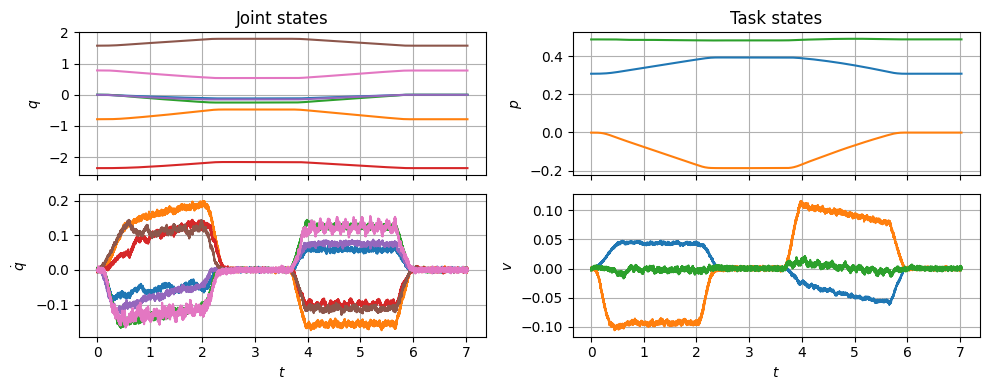

In [16]:
fig, ax = plt.subplots(2, 2, num=1, figsize=(10, 4), sharex=True)

ax[0, 0].plot(tt, qt, "-")
ax[0, 0].grid()
ax[0, 0].set_ylabel("$q$")
ax[0, 0].set_title("Joint states")

ax[1, 0].plot(tt, qdt, "-")
ax[1, 0].grid()
ax[1, 0].set_ylabel("$\\dot q$")
ax[1, 0].set_xlabel("$t$")

ax[0, 1].plot(tt, xt[:, :3], "-")
ax[0, 1].grid()
ax[0, 1].set_ylabel("$p$")
ax[0, 1].set_title("Task states")

ax[1, 1].plot(tt, vt[:, :3], "-")
ax[1, 1].grid()
ax[1, 1].set_ylabel("$v$")
ax[1, 1].set_xlabel("$t$")

fig.tight_layout()

# Contacts and collisions

To detect contacts and to select behaviour of the robot when in contact `panda` class provides  functions:

| Method                                       | Description |
| -------------------------------------------- | ----------- |
| `CheckContacts()`                            | Returns `True` if any joint or Cartesian contact flag in the current Franka state is active. |
| `GetContacts()`                              | Returns the current contact flags as `(joint_contacts, cartesian_contacts)`. |
| `GetCollisions()`                            | Returns the current collision flags as `(joint_collisions, cartesian_collisions)`. |
| `SetCollisionBehavior(tq, F, tq_low, F_low)` | Configures Franka joint-torque and Cartesian force thresholds. <br/>Values between lower and upper thresholds are reported as contacts; values above the upper thresholds are treated as collisions and can stop motion. |


In [ ]:
r.SetCollisionBehavior(tq=10, F=10)

# Status and error recovery

The Panda status methods are a hardware-aware extension of the generic `robot` interface. Instead of only tracking internal flags, they read the current Franka robot mode, report whether the robot is operational, expose non-ready states, and provide a direct recovery call for clearing hardware faults.

| Method | Description |
| --- | --- |
| `isConnected()` | Returns the internal connection flag `_connected`, indicating whether the Panda interface was successfully initialized. |
| `isReady()` | Reads the current Franka state and returns `True` only when the robot mode is one of the ready/operational modes used by this class (`1` or `2`). |
| `isActive()` | Alias for `isReady()`, used to indicate that the robot connection is active and ready for commands. |
| `Check(silent=False)` | Reads the current Franka robot mode and returns a list of detected non-ready status names. An empty list means no status problem was detected. |
| `ErrorRecovery()` | Resets the current target and calls the Franka recovery routine `self.panda.recover()` to clear hardware error states. Returns `0` on completion. |


In [17]:
print("Current robot status:", r.Check())

Current robot status: ['kReflex']


If an error is reported, `ErrorRecovery` can be used for automatic error recovery. If this procedure is not succesfull, then **Desk** has to be used.

In [18]:
r.ErrorRecovery()

0

In [17]:
print("Current robot status:", r.Check())

Current robot status: []
